In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df =pd.read_csv("/content/wine_clean.csv")

In [7]:
from sklearn.model_selection import train_test_split

In [9]:
y = df['Class']
x =  df.drop(columns= ['Class'])

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [14]:
x_train , x_test , y_train , y_test  = train_test_split(x , y, test_size = 0.3 ,random_state =13 ,stratify = y)

In [29]:
tree = DecisionTreeClassifier()
params = {
    "criterion" :["gini","entropy","log_loss"],
    "splitter" :["best","random"],
    "max_depth" :[2,3,4,5,6,7,None],
    "min_samples_split" :[2,3,4,5,6],
    "max_features" :["sqrt","log2",None]
}
grid=GridSearchCV(estimator = tree , cv =10 , param_grid= params , scoring ="accuracy" , error_score ="raise")

In [30]:
grid.fit(x_train  , y_train)

GridSearchCV(cv=10, error_score='raise', estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, 6, 7, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_split': [2, 3, 4, 5, 6],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [32]:
grid.best_params_

{'criterion': 'log_loss',
 'max_depth': 6,
 'max_features': None,
 'min_samples_split': 6,
 'splitter': 'random'}

In [34]:
grid.best_score_

np.float64(0.9608974358974359)

In [38]:
clf =  DecisionTreeClassifier(criterion = "log_loss" , max_depth = 6 , max_features = None , min_samples_split = 6 , splitter= "random")

In [67]:
# making mesh grid

clf.fit(x_train , y_train)
clf.score(x_test ,y_test)

0.9074074074074074

In [46]:
# obj =  DecisionTreeClassifier(criterion = "log_loss" , max_depth = 6 , max_features = None , min_samples_split = 6 , splitter= "random")

In [59]:
# a = np.arange(x_train.iloc[:,0].min()-1,x_train.iloc[:,0].max()+1,step =0.01)
# b = np.arange(x_train.iloc[:,1].min()-1,x_train.iloc[:,1].max()+1,step =0.01)

In [62]:
# xx,yy = np.meshgrid(a,b)

In [ ]:
# array = np.array([xx.ravel(),yy.ravel()]).T

# RandomForest

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
bagg = RandomForestClassifier(oob_score=True ,criterion = "log_loss" , max_depth = 6 , max_features = None , min_samples_split = 6 )
param = {
    "n_estimators" : [90,100,120,130],

}

In [82]:
g=GridSearchCV(estimator = bagg , cv =10 , param_grid= param , scoring ="accuracy" , error_score ="raise")

In [83]:
g.fit(x_train,y_train)

GridSearchCV(cv=10, error_score='raise',
             estimator=RandomForestClassifier(criterion='log_loss', max_depth=6,
                                              max_features=None,
                                              min_samples_split=6,
                                              oob_score=True),
             param_grid={'n_estimators': [90, 100, 120, 130]},
             scoring='accuracy')

In [87]:
g.best_score_
g.best_params_

{'n_estimators': 100}

In [88]:
bag = RandomForestClassifier(oob_score=True,n_estimators=100 ,criterion = "log_loss" , max_depth = 6 , max_features = None , min_samples_split = 6 )

In [89]:
bag.fit(x_train, y_train)

RandomForestClassifier(criterion='log_loss', max_depth=6, max_features=None,
                       min_samples_split=6, oob_score=True)

In [131]:
bag.oob_score_


0.9516129032258065

In [98]:
bag.score(x_test,y_test)
y_pred =bag.predict(x_test)

In [102]:
from sklearn.metrics import accuracy_score , confusion_matrix , recall_score  , precision_score ,classification_report
from sklearn.model_selection import learning_curve

In [101]:
accuracy_score(y_test , y_pred)

0.9629629629629629

In [104]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           1       1.00      0.94      0.97        18
           2       0.95      0.95      0.95        21
           3       0.94      1.00      0.97        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.96      0.96      0.96        54



In [112]:
size , train_  , test_ = learning_curve(estimator=bag ,X=x_train , y=y_train ,scoring ="accuracy",cv=5,train_sizes =np.linspace(0.3,1,5))

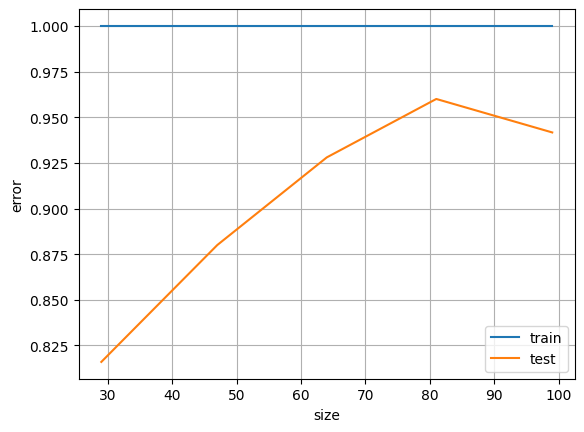

In [116]:
train_ = np.mean(train_,axis =0)
test_ = np.mean(test_,axis =0)
plt.plot(size,train_  , label = "train")
plt.plot(size,test_  , label = "test")
plt.legend()
plt.xlabel("size")
plt.ylabel("error")
plt.grid()
plt.show()

In [126]:
precision_score(y_test , y_pred , average = "macro")

0.9632936507936508